In [ ]:
## Simulation classes are stored in sim.py
import sim

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

OSError: /autofs/nccs-svm1_home1/nkaaz/analysis/macros_dev/libfunctions.so: cannot open shared object file: No such file or directory

In [2]:
### Simulation data is loaded via a Simulation class, given a directory and a dump file, i.e. : 
sim_dir =  "/gpfs/alpine/proj-shared/phy129/T65TOR/"#"/gpfs/alpine/phy129/proj-shared/PLASMOID2048/"#
D = 500

## All flags can be given as arguments
## flatten=1 is equivalent to using rdump_griddata() and rgdump_griddata()
sim_init = sim.Simulation(sim_dir, D, lowres1=16,lowres2=16,lowres3=16,flatten=1)

Running self._readBlockData()
Running self._readParamData()
Running self._read_gdumps_flatten()
Finishing _read_gdumps_flatten().
Running self._read_dump_flatten()
Finishing _read_dump_flatten().
Finished loading data!


In [6]:
## Grid quantities can be derived, for example, with
print(np.shape(sim_init.rho))

## There are several derived quantities (check sim.py for everything listed with @property) that are only calculated after the
## attribute is called
## i.e., velocity in x direction
print(np.shape(sim_init.vx))

(1, 840, 288, 512)
(1, 840, 288, 512)


Text(0, 0.5, '$z [r_{\\rm g}]$')

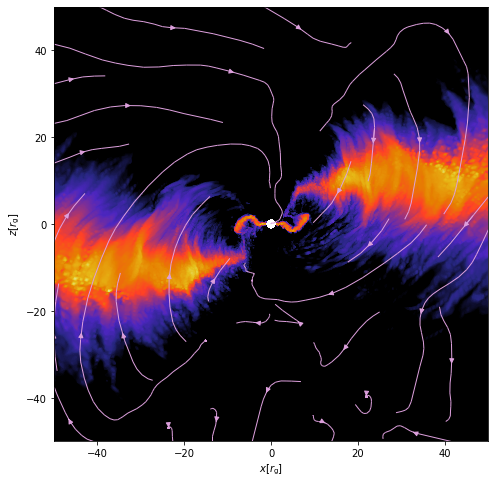

In [13]:
## There are a few ways to plot, the simplest is with Simulation._contourf, which is essentially a wrapper function for plt.contourf()
## Lets plot density, for example:

## We pass the argument as a string, give minimum and maximum values. 

## optional arguments are:
# mode='phi' tells the code to plot in the plane that phi-hat is normal to, i.e. the polar plane
# phi_offset is in degrees and rotates the polar plane along the z axis
# width is the width of the plot in code coordinates
# fill_cells stretchs the ends of the polar grid so there are no gaps

# stream is a dictionary that will overplot streamlines (by default it = None)
# most arguments are matplotlib arguments, you can check Simulation._add_streamplot_to_ax for details
# example for velocity streamlines: 
stream = {'type':'velocity','color':'plum','density':0.4,'linewidth':1,'maxlength' : 4.0}

# other params are self explanatory and you can check the source code for descriptions
fig, ax, cs  = sim_init._contourf('rho', 1e-5, 1,mode='phi',phi_offset=45,
                                         width=100,figsize=(10,8),cmap='CMRmap',fill_cells=1,dolog=1,stream=stream)

# fig = matplotlib figure, ax = matplotlib axis, cs = instead of matplotlib contourf plot
# you can use these to change labels/xticks/yticks
# i.e.
ax.set_xlabel(r'$x [r_{\rm g}]$')
ax.set_ylabel(r'$z [r_{\rm g}]$')

<class 'numpy.ndarray'> (2, 2)


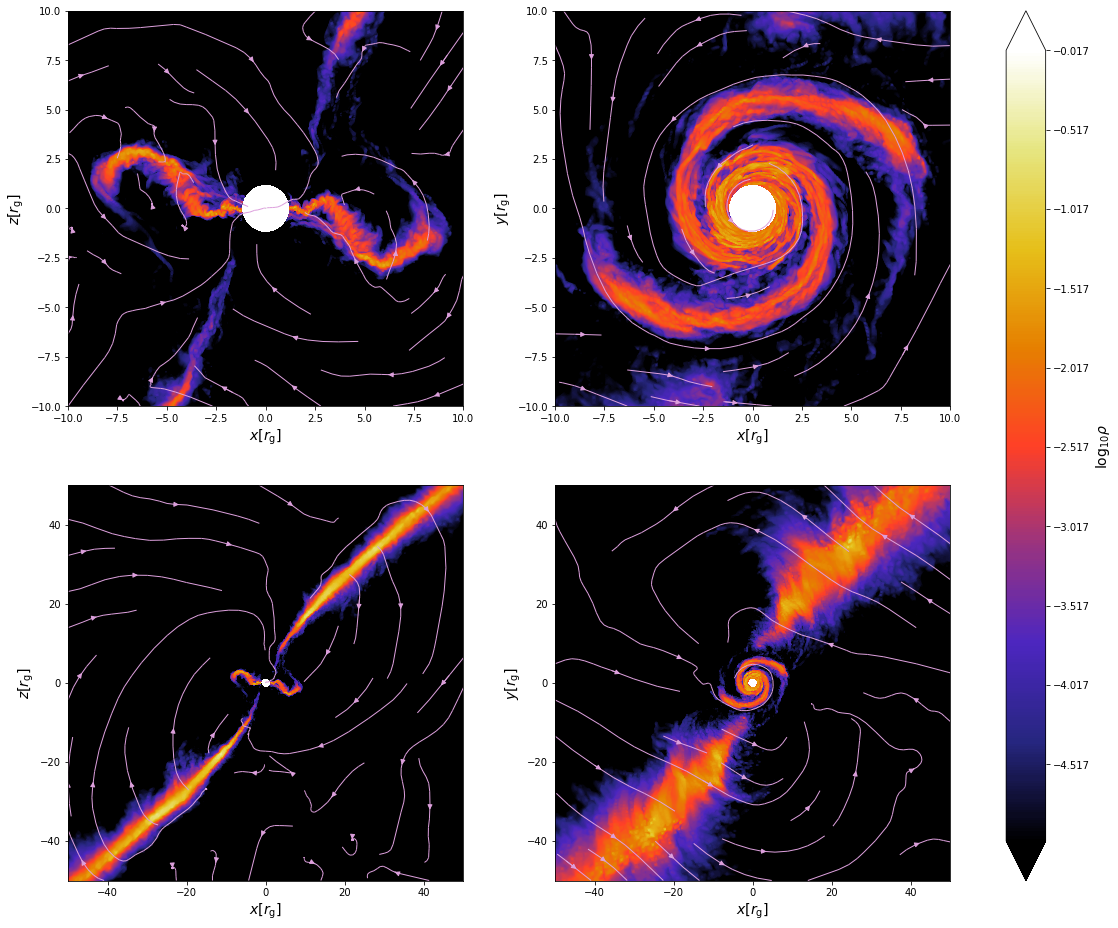

In [19]:
## We can also plot grids of quantities using Simulation._contourf_grid
## It has all the same params as Simulation._contourf, plus a value for rows and cols
## Each parameter can be passed as a single value, or as a list of values with length = rows*cols

## Here, we plot the same as above, but for azimuthal and polar plots at two different widths.
stream = {'type':'velocity','color':'plum','density':0.4,'linewidth':1,'maxlength' : 4.0}


fig, axs, cs  = sim_init._contourf_grid('rho', 1e-5, 1,mode=['phi','theta','phi','theta'],phi_offset=0,
                                         width=[20,20,100,100],figsize=(20,16),cmap='CMRmap',fill_cells=1,
                                        dolog=1,stream=stream,rows=2,cols=2)

# now axs and cs are both lists
axs[0].set_xlabel(r'$x [r_{\rm g}]$',fontsize=14)
axs[0].set_ylabel(r'$z [r_{\rm g}]$',fontsize=14)
axs[2].set_xlabel(r'$x [r_{\rm g}]$',fontsize=14)
axs[2].set_ylabel(r'$z [r_{\rm g}]$',fontsize=14)
axs[1].set_xlabel(r'$x [r_{\rm g}]$',fontsize=14)
axs[1].set_ylabel(r'$y [r_{\rm g}]$',fontsize=14)
axs[3].set_xlabel(r'$x [r_{\rm g}]$',fontsize=14)
axs[3].set_ylabel(r'$y [r_{\rm g}]$',fontsize=14)

# lets add a colorbar this time too
cb = fig.colorbar(cs[-1], ax=axs)
cb.set_label(r'${\rm log}_{10}\rho$',fontsize=14)

In [ ]:
## Okay, what if we want to do something a little more complicated?
## Lets say we want this same 2x2 grid, but we want another column on the left, that shows tilt and precession profiles
## Then we have to manually create the figure and use the Simulation._add_contourf_to_ax function, which takes all the same arguments as Simulation._contourf except the first argument is the axis to plot on.

# create figure
fig,axs = plt.subplots(2,3,figsize=(15,8))

#### Lets do contourf plots first

# contourf plots to axes
field = 'rho'
fmin  = 1e-5
fmax  = 1
stream = {'type':'velocity','color':'plum','density':0.4,'linewidth':1,'maxlength' : 4.0}
ax, cs = sim_init._add_contourf_to_ax(axs[0,1], field, fmin, fmax, 20,mode='phi',phi_offset=0,fill_cells=1,dolog=1,cmap='CMRmap',stream=stream)
ax, cs = sim_init._add_contourf_to_ax(axs[0,2], field, fmin, fmax, 20,mode='theta',phi_offset=0,fill_cells=1,dolog=1,cmap='CMRmap',stream=stream)
ax, cs = sim_init._add_contourf_to_ax(axs[1,1], field, fmin, fmax, 100,mode='phi',phi_offset=0,fill_cells=1,dolog=1,cmap='CMRmap',stream=stream)
ax, cs = sim_init._add_contourf_to_ax(axs[1,2], field, fmin, fmax, 100,mode='theta',phi_offset=0,fill_cells=1,dolog=1,cmap='CMRmap',stream=stream)

# set their axis labels
axs[0,1].set_xlabel(r'$x\,[R_{\rm a}]$',fontsize=14)
axs[0,1].set_ylabel(r'$z\,[R_{\rm a}]$',fontsize=14)
axs[1,1].set_xlabel(r'$x\,[R_{\rm a}]$',fontsize=14)
axs[1,1].set_ylabel(r'$z\,[R_{\rm a}]$',fontsize=14)

axs[0,2].set_xlabel(r'$x\,[R_{\rm a}]$',fontsize=14)
axs[0,2].set_ylabel(r'$y\,[R_{\rm a}]$',fontsize=14)
axs[1,2].set_xlabel(r'$x\,[R_{\rm a}]$',fontsize=14)
axs[1,2].set_ylabel(r'$y\,[R_{\rm a}]$',fontsize=14)

### Lets plot precession and tilt profiles now
# The first time tilt or precession quantities are called will be slower because it has to call the _warp_disk() kernel in C
# to do the computations

# tilt
axs[0,0].plot(sim_init.r[0,:,0,0],sim_init.tilt_disk[0],color='darkblue')
axs[0,0].set_xlim(0,50)
axs[0,0].set_xlabel(r'$r\,[r_{\rm g}]$',fontsize=14)
axs[0,0].set_ylabel(r'$T\,[{}^\circ]$',fontsize=14)

# prec
axs[1,0].plot(sim_init.r[0,:,0,0],sim_init.prec_disk[0],color='darkred')
axs[1,0].set_xlim(0,50)
axs[1,0].set_xlabel(r'$r\,[r_{\rm g}]$',fontsize=14)
axs[1,0].set_ylabel(r'$P\,[{}^\circ]$',fontsize=14)

# plt.tight_layout will fix spacing between axes (usually...)
plt.tight_layout()

# add colorbar (after subplots tight_layout)
# sometimes this squeezes the axes and makes labels overlap; this is because the colorbar eats away
# a fraction of the existing axes. default is fraction=0.15 so I make it smaller here
cb = fig.colorbar(cs, ax=axs, fraction=0.05)
cb.set_label(r'${\rm log}_{10}(\rho)$',fontsize=14)


/autofs/nccs-svm1_home1/nkaaz/analysis/macros_dev/sim.py:1779: RuntimeWarning: invalid value encountered in log10
  f    = np.log10(f)
/autofs/nccs-svm1_home1/nkaaz/analysis/macros_dev/sim.py:1521: RuntimeWarning: invalid value encountered in true_divide
  h_ax_R = np.arccos(z_ax_R/r_ax_R)
